<a href="https://colab.research.google.com/github/cidcom/satellite-cloud-removal-dip/blob/main/01-Example-Use-colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

ModuleNotFoundError: No module named 'imp'

# GitHub import and package installation
These two actions should take about 1-2 minutes. Then you're ready to go.

🚀 **To use GPU go to** `Runtime` -> `Change Runtime Type` -> `Hardware Accelerator: GPU`

In [3]:
! git clone https://github.com/cidcom/satellite-cloud-removal-dip

Cloning into 'satellite-cloud-removal-dip'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 106 (delta 41), reused 52 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 7.23 MiB | 13.97 MiB/s, done.
Resolving deltas: 100% (41/41), done.


In [4]:
!pip install -q rasterio lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 49.6 MB/s eta 0:00:00


In [5]:
import sys
sys.path.append('./satellite-cloud-removal-dip/')

from src import *
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['figure.figsize'] = (20, 10)

## Example Cloud Image with a Cloud-Shadow Mask 🌥

In [6]:
s2_image = s2_preprocess('./satellite-cloud-removal-dip/data/example_sample/S2/S1_3c120554-3873-4de2-bcc3-23ae00d28c4f_S2_76dac503-47d7-446b-b92d-56f4dd10f8e2_0_0_256x256.tif')

with open('./satellite-cloud-removal-dip/data/example_sample/mask.npy', 'rb') as f:
    mask = np.load(f)

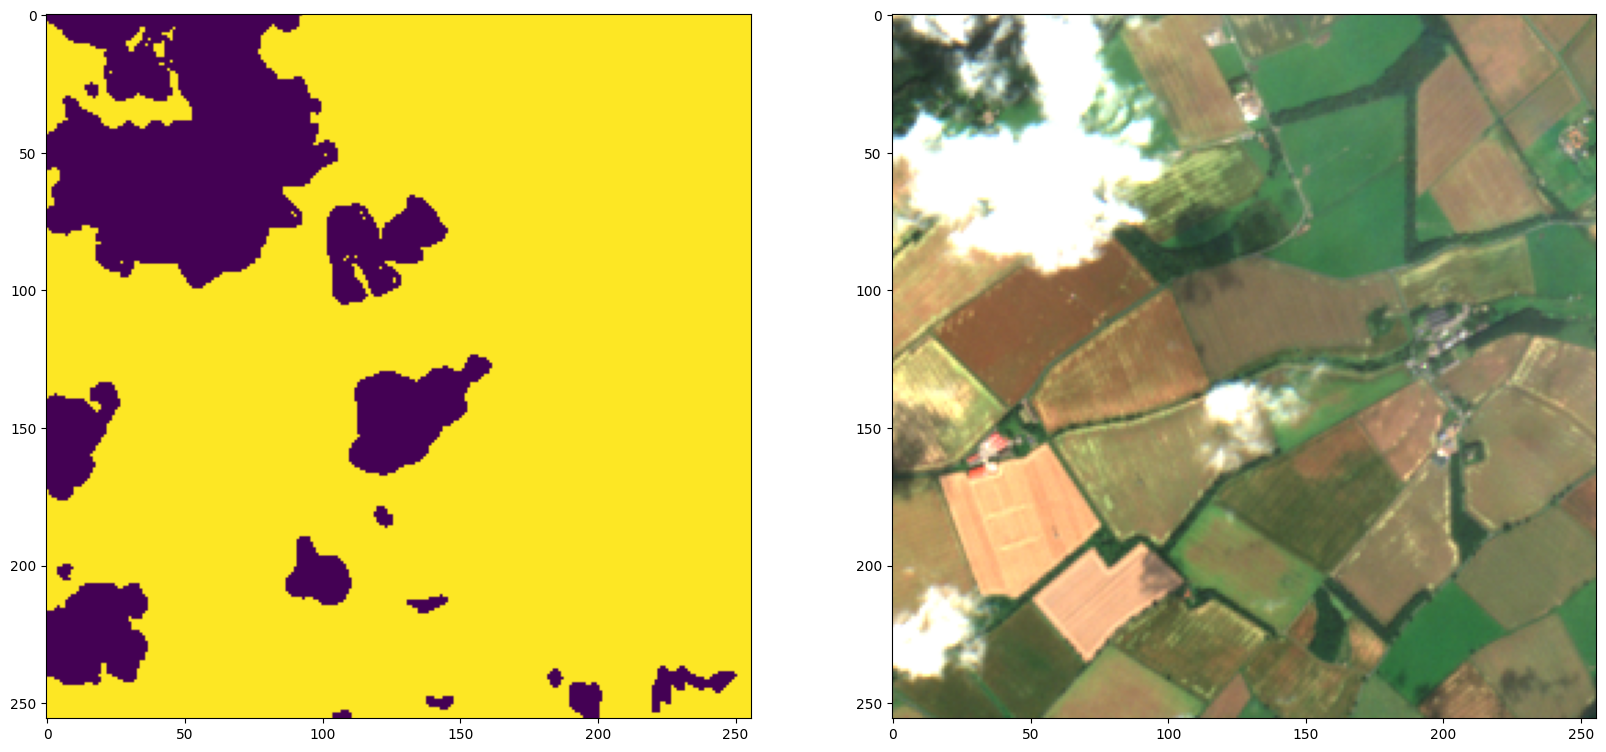

In [7]:
plt.subplot(1,2,1)
plt.imshow(mask)
plt.subplot(1,2,2)
plt.imshow(s2_image)

### Supporting Data: Sentinel-1 SAR and a yearly Sentinel-2 average from 2019

In [8]:
s1_image = s1_preprocess('./satellite-cloud-removal-dip/data/example_sample/S1/S1_3c120554-3873-4de2-bcc3-23ae00d28c4f_S2_76dac503-47d7-446b-b92d-56f4dd10f8e2_0_0_256x256.tif',
                         to_db = True)

with open('./satellite-cloud-removal-dip/data/2019_mean.npy', 'rb') as f:
    s2_mean = np.load(f)

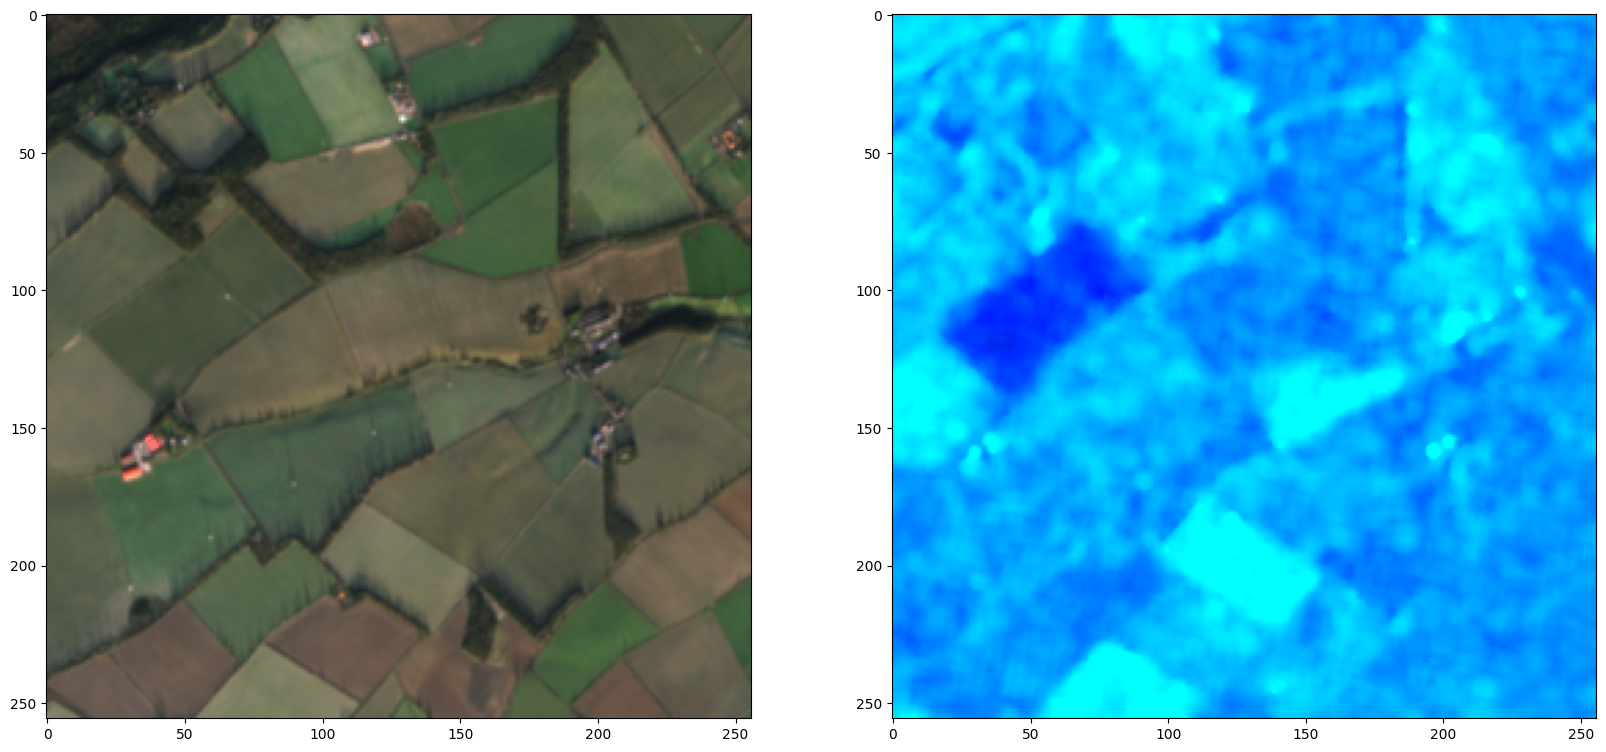

In [9]:
plt.subplot(1,2,1)
plt.imshow(s2_mean)
plt.subplot(1,2,2)
plt.imshow(rgb(s1_image))

## Initialize Model and Train 🏋
The ttraining should take about 10 minutes with the resources provided by Google Colab

In [10]:
my_model = LitDIP()

my_model.set_target([s2_image, s2_mean, s1_image])
my_model.set_mask([mask,
                   np.ones(mask.shape),
                   np.ones(mask.shape)])

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [11]:
trainer = pl.Trainer(
    max_epochs=4,
    logger=False,
    accelerator="cpu",
    devices=1
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [12]:
result, _, _ = my_model.output() # the two unused (_) variables correspond to s2_mean reconstruction and s1_image reconstruction

Text(0.5, 1.0, 'Results')

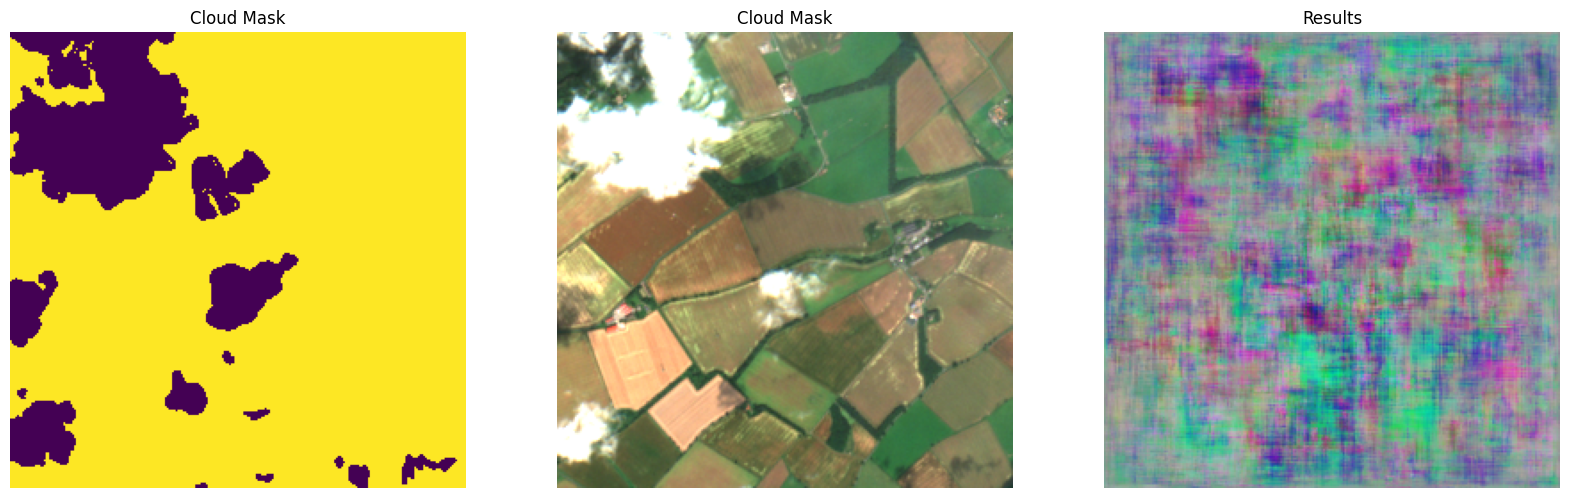

In [13]:
plt.subplot(1,3,1)
plt.imshow(mask)
plt.axis('off')
plt.title('Cloud Mask')
plt.subplot(1,3,2)
plt.imshow(s2_image)
plt.axis('off')
plt.title('Cloud Mask')
plt.subplot(1,3,3)
plt.imshow(result)
plt.axis('off')
plt.title('Results')

In [14]:
!unzip "/content/archive.zip" -d "/content/dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/EuroSAT_RGB/River/River_1449.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_145.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1450.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1451.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1452.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1453.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1454.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1455.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1456.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1457.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1458.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1459.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_146.jpg  
  inflating: /content/dataset/EuroSAT_RGB/River/River_1460.jpg  
  inflating: /content/dataset/EuroSAT_RGB

In [15]:
!find /content/dataset

Streaming output truncated to the last 5000 lines.
/content/dataset/EuroSAT_RGB/River/River_1565.jpg
/content/dataset/EuroSAT_RGB/River/River_395.jpg
/content/dataset/EuroSAT_RGB/River/River_1580.jpg
/content/dataset/EuroSAT_RGB/River/River_916.jpg
/content/dataset/EuroSAT_RGB/River/River_2046.jpg
/content/dataset/EuroSAT_RGB/River/River_1425.jpg
/content/dataset/EuroSAT_RGB/River/River_19.jpg
/content/dataset/EuroSAT_RGB/River/River_241.jpg
/content/dataset/EuroSAT_RGB/River/River_837.jpg
/content/dataset/EuroSAT_RGB/River/River_1436.jpg
/content/dataset/EuroSAT_RGB/River/River_952.jpg
/content/dataset/EuroSAT_RGB/River/River_1411.jpg
/content/dataset/EuroSAT_RGB/River/River_1838.jpg
/content/dataset/EuroSAT_RGB/River/River_20.jpg
/content/dataset/EuroSAT_RGB/River/River_1952.jpg
/content/dataset/EuroSAT_RGB/River/River_2235.jpg
/content/dataset/EuroSAT_RGB/River/River_1433.jpg
/content/dataset/EuroSAT_RGB/River/River_2465.jpg
/content/dataset/EuroSAT_RGB/River/River_1936.jpg
/content

In [16]:
!unzip -q "/content/archive (1).zip" -d /content/RICE

In [17]:
!find /content/RICE | head -20

/content/RICE
/content/RICE/RICE
/content/RICE/RICE/RICE2
/content/RICE/RICE/RICE2/label
/content/RICE/RICE/RICE2/label/572.png
/content/RICE/RICE/RICE2/label/240.png
/content/RICE/RICE/RICE2/label/710.png
/content/RICE/RICE/RICE2/label/109.png
/content/RICE/RICE/RICE2/label/547.png
/content/RICE/RICE/RICE2/label/705.png
/content/RICE/RICE/RICE2/label/582.png
/content/RICE/RICE/RICE2/label/289.png
/content/RICE/RICE/RICE2/label/291.png
/content/RICE/RICE/RICE2/label/606.png
/content/RICE/RICE/RICE2/label/622.png
/content/RICE/RICE/RICE2/label/437.png
/content/RICE/RICE/RICE2/label/301.png
/content/RICE/RICE/RICE2/label/480.png
/content/RICE/RICE/RICE2/label/732.png
/content/RICE/RICE/RICE2/label/57.png


In [18]:
!ls /content/RICE/RICE/RICE2

cloud  label  mask  Test


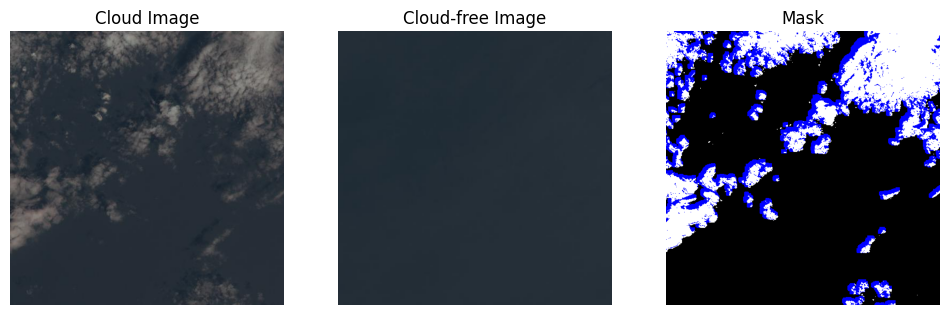

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

cloud = Image.open('/content/RICE/RICE/RICE2/cloud/1.png')
label = Image.open('/content/RICE/RICE/RICE2/label/1.png')
mask = Image.open('/content/RICE/RICE/RICE2/mask/1.png')

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cloud)
plt.title("Cloud Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(label)
plt.title("Cloud-free Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")

plt.show()

In [20]:
s2_image

array([[[1.247 , 1.14  , 0.874 ],
        [1.194 , 1.084 , 0.789 ],
        [1.119 , 1.016 , 0.735 ],
        ...,
        [0.594 , 0.522 , 0.387 ],
        [0.5055, 0.5105, 0.3855],
        [0.442 , 0.4945, 0.3255]],

       [[0.922 , 0.813 , 0.568 ],
        [0.81  , 0.683 , 0.4845],
        [0.755 , 0.671 , 0.46  ],
        ...,
        [0.509 , 0.525 , 0.3665],
        [0.443 , 0.502 , 0.343 ],
        [0.47  , 0.486 , 0.328 ]],

       [[0.568 , 0.541 , 0.3705],
        [0.4895, 0.49  , 0.3555],
        [0.4715, 0.463 , 0.35  ],
        ...,
        [0.4105, 0.4985, 0.3165],
        [0.481 , 0.503 , 0.3305],
        [0.515 , 0.481 , 0.3515]],

       ...,

       [[0.4855, 0.529 , 0.3365],
        [0.553 , 0.545 , 0.3525],
        [0.586 , 0.575 , 0.3535],
        ...,
        [0.1875, 0.2455, 0.2155],
        [0.189 , 0.2455, 0.212 ],
        [0.171 , 0.244 , 0.2295]],

       [[0.574 , 0.575 , 0.355 ],
        [0.601 , 0.569 , 0.3505],
        [0.609 , 0.572 , 0.3595],
        .

In [21]:
import os

print(os.listdir('/content/RICE/RICE/RICE2/cloud')[:5])
print(os.listdir('/content/RICE/RICE/RICE2/label')[:5])
print(os.listdir('/content/RICE/RICE/RICE2/mask')[:5])

['572.png', '240.png', '710.png', '109.png', '547.png']
['572.png', '240.png', '710.png', '109.png', '547.png']
['572.png', '240.png', '710.png', '109.png', '547.png']


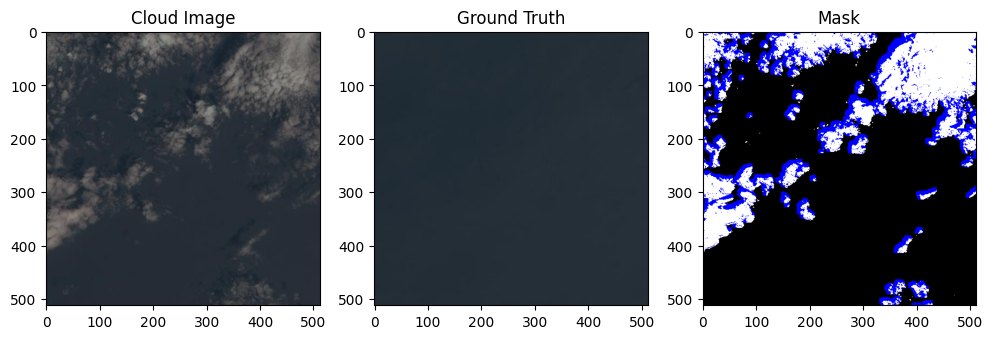

In [22]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

cloud = np.array(Image.open('/content/RICE/RICE/RICE2/cloud/1.png'))
label = np.array(Image.open('/content/RICE/RICE/RICE2/label/1.png'))
mask = np.array(Image.open('/content/RICE/RICE/RICE2/mask/1.png'))

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(cloud)
plt.title("Cloud Image")

plt.subplot(132)
plt.imshow(label)
plt.title("Ground Truth")

plt.subplot(133)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.show()

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]], dtype=uint8)
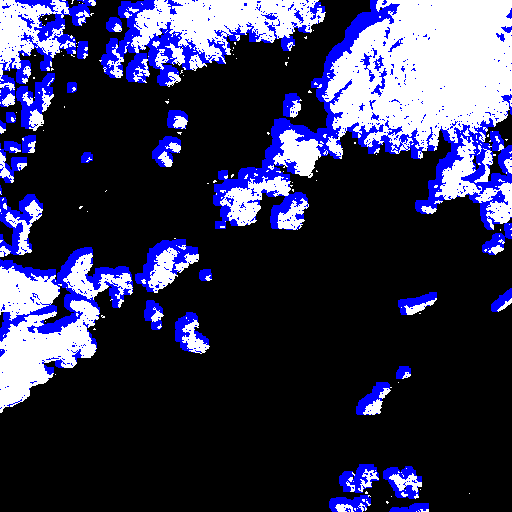

In [23]:
s2_image
s2_mean
mask

In [25]:
print(cloud.shape)
print(label.shape)
print(mask.shape)

(512, 512, 3)
(512, 512, 3)
(512, 512, 3)


In [32]:
s2_image = cloud.astype("float32") / 255.0
s2_mean = label.astype("float32") / 255.0
mask = mask.astype("float32") / 255.0

In [35]:
my_model = LitDIP()

my_model.set_target([s2_image, s2_mean, s2_image])

my_model.set_mask([
    mask,
    np.ones(mask.shape),
    np.ones(mask.shape)
])

In [37]:
my_model.train()

LitDIP(
  (model): Sequential(
    (1): Sequential(
      (1): Sequential(
        (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      )
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): LeakyReLU(negative_slope=0.2, inplace=True)
      (4): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): LeakyReLU(negative_slope=0.2, inplace=True)
      (7): Sequential(
        (1): Sequential(
          (1): Sequential(
            (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          )
          (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (3): LeakyReLU(negative_slope=0.2, inplace=True)
          (4): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   